<a href="https://colab.research.google.com/github/dontaedawkins9-ux/IS-362/blob/main/IS362_Project1.ipynb." target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IS 362 – Project 1: Airline Arrival Delays

This project analyzes arrival delays for Alaska Airlines and AM West across five destinations. The data will be stored in a CSV file, loaded into pandas, and analyzed to compare the arrival performance of the two airlines.

In [43]:
import pandas as pd

In [44]:
data = {
    'Airline': [
        'Alaska', 'Alaska', 'Alaska', 'Alaska', 'Alaska',
        'AM West', 'AM West', 'AM West', 'AM West', 'AM West'
    ],
    'Destination': [
        'Los Angeles', 'Phoenix', 'San Diego', 'San Francisco', 'Seattle',
        'Los Angeles', 'Phoenix', 'San Diego', 'San Francisco', 'Seattle'
    ],
    'On Time': [
        497, 221, 212, 503, 1841,
        694, 4840, 383, 320, 201
    ],
    'Delayed': [
        62, 12, 20, 102, 305,
        117, 415, 65, 129, 61
    ]
}

airline_data = pd.DataFrame(data)

airline_data.to_csv('airline_delays.csv', index=False)

airline_data

,Airline,Destination,On Time,Delayed
0,Alaska,Los Angeles,497,62
1,Alaska,Phoenix,221,12
2,Alaska,San Diego,212,20
3,Alaska,San Francisco,503,102
4,Alaska,Seattle,1841,305
5,AM West,Los Angeles,694,117
6,AM West,Phoenix,4840,415
7,AM West,San Diego,383,65
8,AM West,San Francisco,320,129
9,AM West,Seattle,201,61


## Reading the CSV File

The airline arrival data is stored in a CSV file. I will use pandas to read the CSV file into a DataFrame so that the data can be analyzed.

In [45]:
df = pd.read_csv('airline_delays.csv')

df

,Airline,Destination,On Time,Delayed
0,Alaska,Los Angeles,497,62
1,Alaska,Phoenix,221,12
2,Alaska,San Diego,212,20
3,Alaska,San Francisco,503,102
4,Alaska,Seattle,1841,305
5,AM West,Los Angeles,694,117
6,AM West,Phoenix,4840,415
7,AM West,San Diego,383,65
8,AM West,San Francisco,320,129
9,AM West,Seattle,201,61


## Analysis of Arrival Delays

To compare the two airlines fairly, I will calculate the total number of flights and the percentage of flights that were delayed for each destination. A delay percentage is more useful than only comparing the number of delayed flights because the airlines have different numbers of total flights.

In [46]:
df['Total Flights'] = df['On Time'] + df['Delayed']

df['Delay Percentage'] = (
    df['Delayed'] / df['Total Flights'] * 100
).round(2)

df

,Airline,Destination,On Time,Delayed,Total Flights,Delay Percentage
0,Alaska,Los Angeles,497,62,559,11.09
1,Alaska,Phoenix,221,12,233,5.15
2,Alaska,San Diego,212,20,232,8.62
3,Alaska,San Francisco,503,102,605,16.86
4,Alaska,Seattle,1841,305,2146,14.21
5,AM West,Los Angeles,694,117,811,14.43
6,AM West,Phoenix,4840,415,5255,7.90
7,AM West,San Diego,383,65,448,14.51
8,AM West,San Francisco,320,129,449,28.73
9,AM West,Seattle,201,61,262,23.28


## Overall Comparison by Airline

Next, I will combine the results from all five destinations to compare the overall delay performance of Alaska and AM West.

In [47]:
airline_summary = df.groupby('Airline')[['On Time', 'Delayed']].sum()

airline_summary['Total Flights'] = (
    airline_summary['On Time'] + airline_summary['Delayed']
)

airline_summary['Delay Percentage'] = (
    airline_summary['Delayed'] / airline_summary['Total Flights'] * 100
).round(2)

airline_summary

,On Time,Delayed,Total Flights,Delay Percentage
Airline,,,,
AM West,6438,787,7225,10.89
Alaska,3274,501,3775,13.27


## Delay Percentage by Destination

The overall percentages provide a useful comparison, but the airlines may perform differently depending on the destination. The following table compares the delay percentage for Alaska and AM West at each of the five destinations.

In [48]:
destination_comparison = df.pivot(
    index='Destination',
    columns='Airline',
    values='Delay Percentage'
)

destination_comparison

Airline,AM West,Alaska
Destination,,
Los Angeles,14.43,11.09
Phoenix,7.90,5.15
San Diego,14.51,8.62
San Francisco,28.73,16.86
Seattle,23.28,14.21


## Visual Comparison of Delay Percentages

The chart below compares the percentage of delayed flights for Alaska and AM West at each destination. This makes it easier to see how the airlines performed across the five cities.

<Axes: title={'center': 'Delay Percentage by Destination'}, xlabel='Destination'>

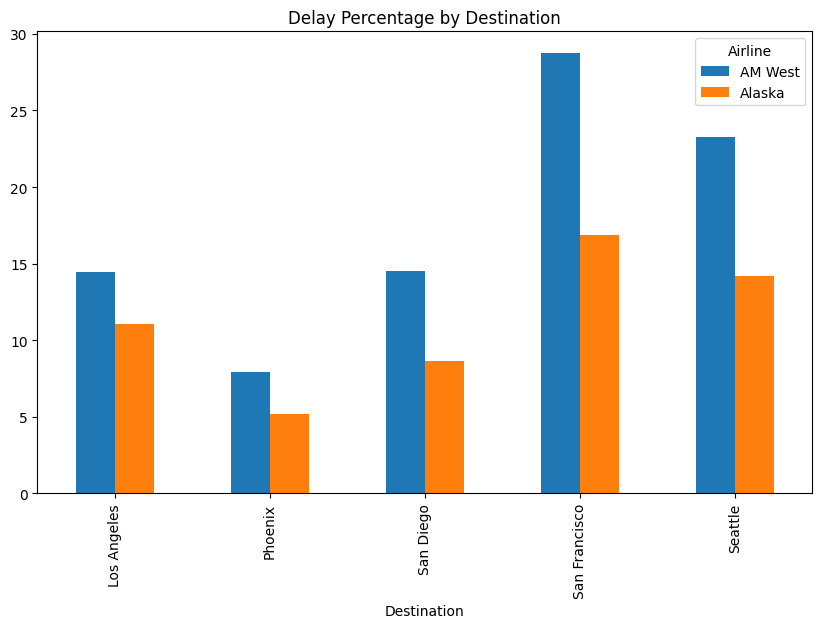

In [49]:
destination_comparison.plot(
    kind='bar',
    figsize=(10, 6),
    title='Delay Percentage by Destination'
)

## Conclusion

After analyzing the arrival data for Alaska and AM West, I found that the two airlines had different results depending on how the data was compared. Alaska had 501 delayed flights out of 3,775 total flights, giving it an overall delay percentage of about 13.27%. AM West had 787 delayed flights out of 7,225 total flights, giving it an overall delay percentage of about 10.89%.

Based only on the overall percentages, AM West had a lower percentage of delayed flights. However, when I compared the airlines at each individual destination, Alaska had a lower delay percentage at all five destinations: Los Angeles, Phoenix, San Diego, San Francisco, and Seattle.

This shows why it is important to look closely at how data is distributed instead of relying only on an overall percentage. AM West had a large number of flights going to Phoenix, where its delay percentage was relatively low. This helped lower AM West's overall delay percentage. The destination-by-destination comparison gives a different perspective and shows that Alaska had a lower delay percentage at each individual destination in this dataset.